# COVID-19: The First 56 Days in the Supplied Snapshot
**Hamed Dhiaa · Python / pandas / Matplotlib**

A historical data-analysis project covering **22 January–17 March 2020**. This Python adaptation of a supplied DataCamp R exercise checks source consistency, reconstructs country-level totals and visualizes reported confirmed cases.

Reported confirmed cases are not all infections. Reporting, testing and definition changes affect these curves. This notebook does not estimate policy effects, transmission rates or future outcomes. It is a historical portfolio analysis, not a current public-health dashboard.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold"})
BLUE, TEAL, GOLD = "#245d80", "#229b91", "#d99538"
def read_data(name):
    return pd.read_csv(Path("datasets") / name, parse_dates=["date"])
world = read_data("confirmed_cases_worldwide.csv").sort_values("date")
regions = read_data("confirmed_cases_china_vs_world.csv").sort_values(["is_china", "date"])
country_rows = read_data("confirmed_cases_by_country.csv")
legacy_top7 = read_data("confirmed_cases_top7_outside_china.csv")
raw = read_data("coronavirus_dataset.csv")
events = read_data("who_events.csv").sort_values("date")
regional = regions.pivot(index="date", columns="is_china", values="cum_cases").rename(columns={"Not China": "Outside China"})
start, end = world.date.min(), world.date.max()
print(f"Historical window: {start:%d %b %Y} to {end:%d %b %Y} ({len(world)} days)")
print(f"Final reported worldwide total: {world.cum_cases.iloc[-1]:,}")
print("All data are read locally; no live data or external image requests.")

Historical window: 22 Jan 2020 to 17 Mar 2020 (56 days)
Final reported worldwide total: 197,146
All data are read locally; no live data or external image requests.


## 1. Reconstruct and reconcile before plotting
The outside-China file has province rows. Its supplied cumulative field contains intermediate country running totals within a date; summing that field would overcount. Instead, sum **daily `cases` by country and date**, then accumulate in date order. Keep negative daily corrections, because removing them would inflate the totals.

The first date is an opening balance, not a measured day of new infections. The first point is retained in cumulative totals but excluded from daily-change plots. Geographic labels are retained as supplied, including non-country entities such as cruise ships.

In [2]:
def aggregate_country_rows(frame):
    result = frame.groupby(["country", "date"], as_index=False)["cases"].sum()
    result = result.sort_values(["country", "date"]).reset_index(drop=True)
    result["cum_cases"] = result.groupby("country")["cases"].cumsum()
    return result
countries = aggregate_country_rows(country_rows)
world_series = world.set_index("date").cum_cases
outside_series = countries.groupby("date").cum_cases.sum()
reconciliation = pd.DataFrame({"World file": world_series, "China plus outside China": regional.sum(axis=1), "Rebuilt outside China": outside_series, "Regional outside China": regional["Outside China"]})
reconciliation["World difference"] = reconciliation["World file"] - reconciliation["China plus outside China"]
reconciliation["Outside difference"] = reconciliation["Rebuilt outside China"] - reconciliation["Regional outside China"]
display(reconciliation.tail())
print(f"Country/province records: {len(country_rows):,}; reconstructed country-date rows: {len(countries):,}")
print(f"Repeated country-date rows in supplied top-seven file: {legacy_top7.duplicated(['country','date']).sum():,}")
print(f"Negative province-level daily corrections retained: {country_rows.cases.lt(0).sum()}")

raw_confirmed = raw.loc[raw.type.eq("confirmed")]
raw_world = raw_confirmed.groupby("date").cases.sum().sort_index().cumsum()
audit = pd.concat([world_series.rename("Analysis snapshot"), raw_world.rename("Raw archive snapshot")], axis=1)
audit["Difference: raw minus analysis"] = audit["Raw archive snapshot"] - audit["Analysis snapshot"]
display(audit.loc[audit["Difference: raw minus analysis"].fillna(1).ne(0)])
print(f"Raw archive ends {raw_confirmed.date.max():%d %b %Y}; analysis snapshot ends {end:%d %b %Y}.")

,World file,China plus outside China,Rebuilt outside China,Regional outside China,World difference,Outside difference
date,,,,,,
2020-03-13,145193,145193,64248,64248,0,0
2020-03-14,156097,156097,75120,75120,0,0
2020-03-15,167449,167449,86446,86446,0,0
2020-03-16,181531,181531,100498,100498,0,0
2020-03-17,197146,197146,116088,116088,0,0


Country/province records: 13,272; reconstructed country-date rows: 8,456
Repeated country-date rows in supplied top-seven file: 1,827
Negative province-level daily corrections retained: 14


,Analysis snapshot,Raw archive snapshot,Difference: raw minus analysis
date,,,
2020-03-16,181531,181546.0,15.0
2020-03-17,197146,NaN,NaN


Raw archive ends 16 Mar 2020; analysis snapshot ends 17 Mar 2020.


The world, region and reconstructed country series reconcile exactly across all 56 dates. The broader raw archive ends one day earlier and differs from the worldwide analysis file by **15 cases on 16 March**. These snapshots are not merged or silently patched.

The precomputed top-seven file repeats country-date rows and includes intermediate totals. It is retained for provenance, but all rankings and country plots below are rebuilt from daily counts.

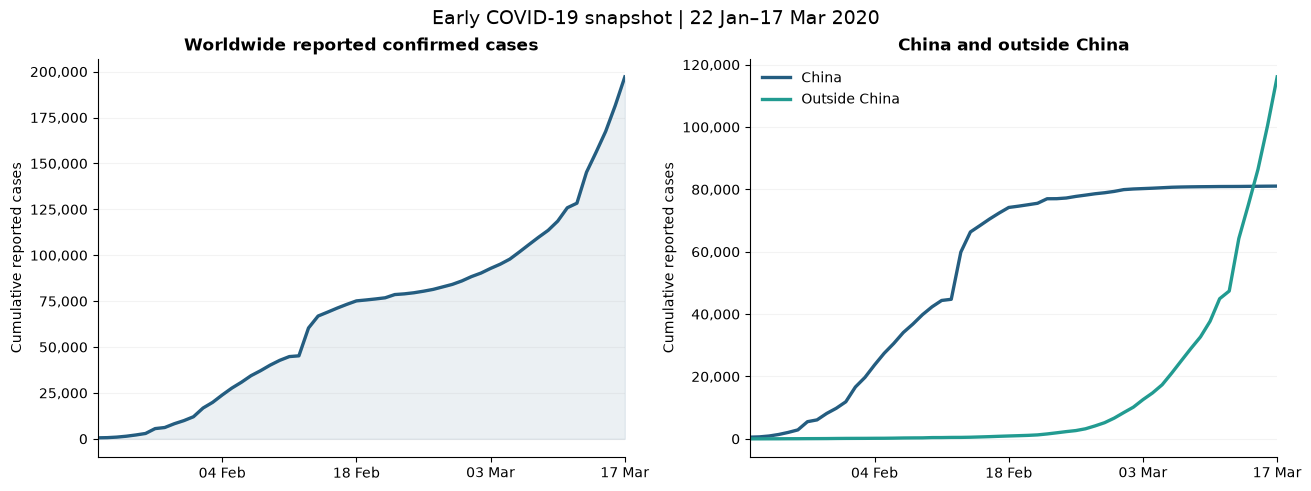

First date outside-China total exceeds China in this snapshot: 15 March 2020.


is_china,China,Outside China
date,,
2020-03-15,81003,86446
2020-03-17,81058,116088


In [3]:
def format_time(ax):
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.grid(axis="y", alpha=0.15)
    ax.set_xlim(start, end)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
axes[0].plot(world.date, world.cum_cases, color=BLUE, linewidth=2.4)
axes[0].fill_between(world.date, world.cum_cases, color=BLUE, alpha=0.09)
axes[0].set(title="Worldwide reported confirmed cases", ylabel="Cumulative reported cases")
for label, color in [("China", BLUE), ("Outside China", TEAL)]:
    axes[1].plot(regional.index, regional[label], label=label, color=color, linewidth=2.4)
axes[1].set(title="China and outside China", ylabel="Cumulative reported cases")
axes[1].legend(frameon=False, loc="upper left")
for ax in axes:
    format_time(ax)
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
fig.suptitle(f"Early COVID-19 snapshot | {start:%d %b}–{end:%d %b %Y}", fontsize=14)
fig.savefig("outbreak_overview.png", dpi=160, facecolor="white")
plt.show()
crossover = regional.index[regional["Outside China"].gt(regional["China"])][0]
print(f"First date outside-China total exceeds China in this snapshot: {crossover:%d %B %Y}.")
display(regional.loc[[crossover, end]])

## 2. Daily reported changes and archived event labels
Daily changes are differences of cumulative reported totals, not dates of infection or symptom onset. A seven-day trailing average smooths reporting variability; it starts only after seven daily changes are available. Negative corrections remain visible if present.

The event labels below come from `who_events.csv` in the exercise archive. They are contextual annotations, not evidence that an event caused a change in the series. In particular, a reporting-definition change can produce a jump without implying the same number of newly infected people that day.

C:\Users\liona\AppData\Local\Temp\ipykernel_19444\3815419257.py:15: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  axes[1].set_xlim(start, end + pd.Timedelta(hours=12))


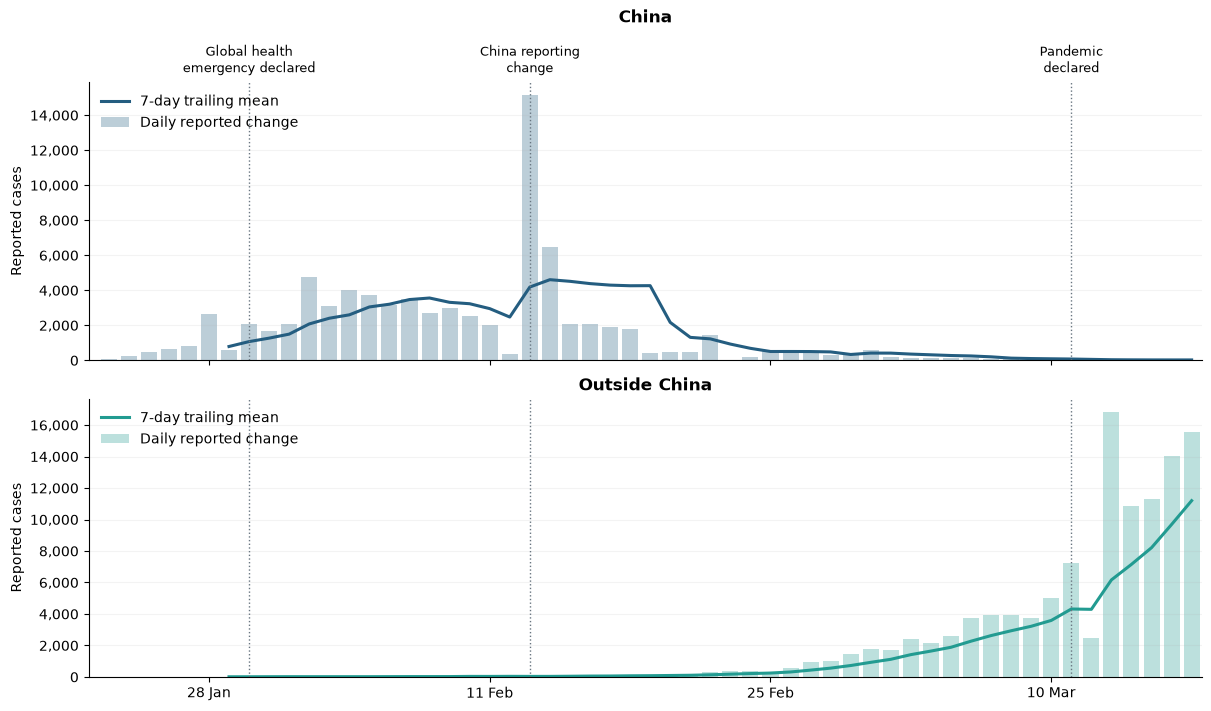

In [4]:
daily_changes = regional.diff().iloc[1:]
rolling = daily_changes.rolling(7, min_periods=7).mean()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, layout="constrained")
for ax, label, color in zip(axes, ["China", "Outside China"], [BLUE, TEAL]):
    ax.bar(daily_changes.index, daily_changes[label], color=color, alpha=0.3, label="Daily reported change")
    ax.plot(rolling.index, rolling[label], color=color, linewidth=2.2, label="7-day trailing mean")
    ax.set(title=label, ylabel="Reported cases")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    format_time(ax)
    ax.legend(frameon=False, loc="upper left")
for event in events.itertuples():
    for ax in axes: ax.axvline(event.date, color="#687580", linestyle=":", linewidth=1)
    axes[0].text(event.date, 1.02, event.event.replace(chr(92) + "n", chr(10)), transform=axes[0].get_xaxis_transform(), ha="center", va="bottom", fontsize=9)
axes[0].set_title("China", loc="center", pad=43)
axes[1].set_xlim(start, end + pd.Timedelta(hours=12))
fig.savefig("daily_reported_changes.png", dpi=160, facecolor="white")
plt.show()

## 3. Largest outside-China totals on the final date
Rank the **final date's reconstructed total**, rather than each location's maximum over time. This respects downward corrections. The ranking uses absolute reported counts, without population adjustment, and does not measure individual risk or comparative outbreak severity.

,country,Reported total on final date
3919,Italy,31506
3695,Iran,16169
7223,Spain,11748
2911,Germany,9257
4311,"Korea, South",8320
2743,France,7699
8063,US,6421


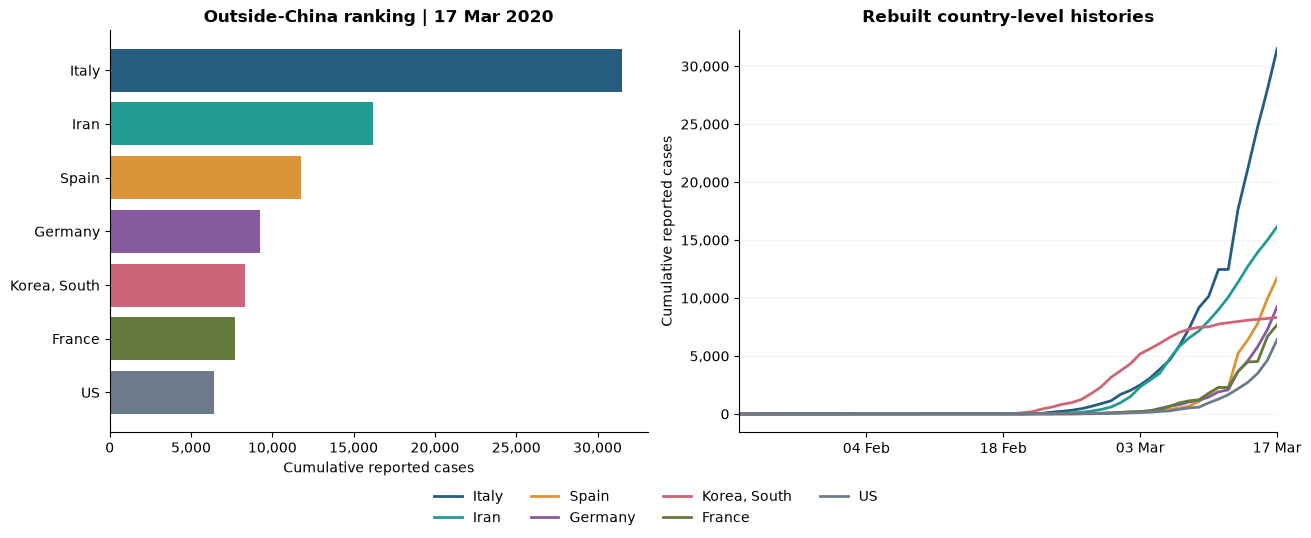

In [5]:
final_totals = countries.loc[countries.date.eq(end)].sort_values(["cum_cases", "country"], ascending=[False, True])
top7 = final_totals.head(7).copy()
top_names = top7.country.tolist()
top_series = countries.loc[countries.country.isin(top_names)]
display(top7[["country", "cum_cases"]].rename(columns={"cum_cases": "Reported total on final date"}))
colors = ["#245d80", "#229b91", "#d99538", "#875a9f", "#cc6677", "#657a3d", "#6b7b8c"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3), layout="constrained")
axes[0].barh(top7.country.iloc[::-1], top7.cum_cases.iloc[::-1], color=colors[::-1])
axes[0].set(title=f"Outside-China ranking | {end:%d %b %Y}", xlabel="Cumulative reported cases")
axes[0].xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
for country, color in zip(top_names, colors):
    series = top_series.loc[top_series.country.eq(country)]
    axes[1].plot(series.date, series.cum_cases, label=country, color=color, linewidth=2)
axes[1].set(title="Rebuilt country-level histories", ylabel="Cumulative reported cases")
format_time(axes[1])
axes[1].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
fig.legend(handles=axes[1].get_lines(), labels=top_names, loc="outside lower center", ncol=4, frameon=False)
fig.savefig("country_comparison.png", dpi=160, facecolor="white")
plt.show()

## 4. The same observations on linear and logarithmic scales
A log axis emphasizes relative change; a linear axis emphasizes absolute change. Both panels show the same positive outside-China totals. An approximately straight segment on a log plot is a descriptive pattern, not a validated exponential forecast. No regression or extrapolation is presented.

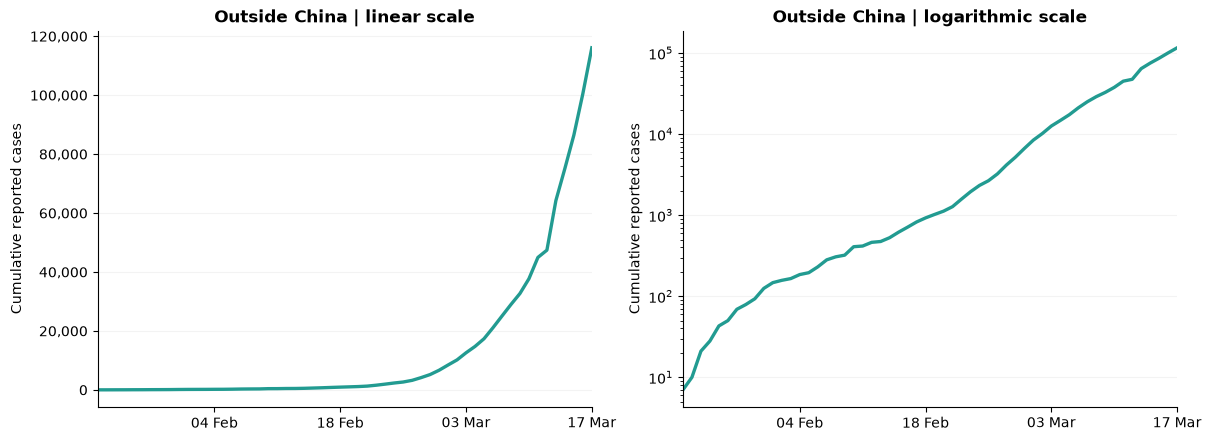

Final total: 197,146 = 81,058 China + 116,088 outside China.
Crossover date in this snapshot: 2020-03-15.
Largest outside-China reported total: Italy, 31,506.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout="constrained")
for ax in axes:
    ax.plot(regional.index, regional["Outside China"], color=TEAL, linewidth=2.4)
    ax.set(ylabel="Cumulative reported cases")
    format_time(ax)
axes[0].set_title("Outside China | linear scale")
axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
axes[1].set(yscale="log", title="Outside China | logarithmic scale")
fig.savefig("linear_and_log_scales.png", dpi=160, facecolor="white")
plt.show()
print(f"Final total: {world_series.iloc[-1]:,} = {regional.loc[end, 'China']:,} China + {regional.loc[end, 'Outside China']:,} outside China.")
print(f"Crossover date in this snapshot: {crossover:%Y-%m-%d}.")
print(f"Largest outside-China reported total: {top7.iloc[0].country}, {top7.iloc[0].cum_cases:,}.")

## What this analysis can and cannot say
The snapshot documents changes in **reported confirmed cases**. Case ascertainment, reporting lags, historical revisions and geographic conventions limit comparability. Without a causal design, population denominators or a transmission model, these charts do not establish the effects of lockdowns, infection risk or future growth.

**Provenance:** adapted from the supplied DataCamp R exercise, whose narrative attributes underlying data to the Rami Krispin `coronavirus` repository and Johns Hopkins CSSE sources. The archive is preserved as received; its six CSVs include differing snapshots. Source-data rights remain with their respective owners. This edition converts the analysis to Python, repairs aggregation, audits reconciliation and adds reproducible tests.